# Position Matters Demo

This notebook reproduces the results presented in the paper **"Position Matters: Feature Inversion Attacks in ViT Split Inference with Token Reduction and Shuffling."**

We demonstrate the performance of our reconstruction attack, **SARA**, as well as two defense mechanisms:

* **Progressive Positional Embedding (PE) Removal**
* **Progressive PE Removal + Adversarial Training**

Experiments are conducted for split points **2, 4, 6, 8, and 10**. For the adversarial defense, results are reported only for split points **2, 4, 6, and 8**.

The figure below illustrates the threat model. During split inference, the edge device transmits the smashed data $h$ to the cloud. An honest-but-curious attacker accesses this intermediate representation and attempts to reconstruct the original input image, denoted by $\tilde{x}$.

<div align="center">
  <img src="images/threat_model.png" alt="Threat model illustration" width="800">
  <p>
    Illustration of the threat model. The edge device transmits the smashed data $h$ to the cloud, where an honest-but-curious attacker attempts to reconstruct the original input image $\tilde{x}$.
  </p>
</div>


## 1. Configure

- `MODEL`: backbone to use, either `"vit"` or `"mae"`
- `CUDA_INDEX`: GPU index when CUDA is available
- `R_VALUE`: tokens merged/dropped per block for ToMe and Dropping
- `IMAGE_INDEX`: index into the sorted `images/` folder


In [1]:
%matplotlib inline

MODEL = "vit"      # "vit" or "mae"
CUDA_INDEX = 0
R_VALUE = 16
IMAGE_INDEX = 0

SARA_SPLITS = (2, 4, 6, 8, 10)
PE_SPLITS = (2, 4, 6, 8, 10)
ADVERSARIAL_SPLITS = (2, 4, 6, 8)  # self-contained checkpoints available for these splits


## 2. Imports And Helpers


In [2]:
from pathlib import Path
import os
import warnings

os.environ.setdefault("PYTORCH_NVML_BASED_CUDA_CHECK", "1")

import numpy as np
import torch
import timm
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

warnings.filterwarnings(
    "ignore",
    message="enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message=r"CUDA initialization: Unexpected error from cudaGetDeviceCount\(\).*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message=r"Can't initialize NVML",
    category=UserWarning,
)

from models.split_vit import ClientVit
from models.tome_vit import ClientVitToMe
from models.rd_vit import ClientVitRD
from models.decoder import AttackerDecoder
from models.position_predictor import ContextualPositionPredictor
from models.mae import TokenToImageDecoder
from utils.attack import SARA
from utils.image import unnormalize
from config import IMAGENET_MEAN, IMAGENET_STD

def _cuda_available() -> bool:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            return torch.cuda.is_available()
    except Exception:
        return False

USE_CUDA = _cuda_available()
DEVICE = f"cuda:{CUDA_INDEX}" if USE_CUDA else "cpu"
ROOT = Path.cwd()
MODELS_ROOT = ROOT / "saved_models" / MODEL
IMAGES_DIR = ROOT / "images"

_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def _to_np(t: torch.Tensor) -> np.ndarray:
    return (unnormalize(t.detach().cpu()).permute(1, 2, 0).numpy() * 255).astype(np.uint8)

def _shuffle_tokens(smashed: torch.Tensor) -> torch.Tensor:
    bsz, tok, dim = smashed.shape
    cls_tok = smashed[:, :1, :]
    patches = smashed[:, 1:, :]
    n = patches.shape[1]
    perms = torch.stack([torch.randperm(n, device=smashed.device) for _ in range(bsz)])
    shuffled = patches[torch.arange(bsz, device=smashed.device).unsqueeze(1), perms]
    return torch.cat([cls_tok, shuffled], dim=1)

def _load_vit() -> torch.nn.Module:
    if MODEL == "mae":
        vit = timm.create_model("vit_base_patch16_224.mae", pretrained=True, num_classes=1000).to(DEVICE).eval()
        lp = torch.load(MODELS_ROOT / "linear_probe_last_block.pth", map_location=DEVICE, weights_only=False)
        vit.head.load_state_dict(lp["head_state_dict"])
        vit.blocks[-1].load_state_dict(lp["last_block_state_dict"])
        vit.norm.load_state_dict(lp["norm_state_dict"])
        return vit
    return timm.create_model("vit_base_patch16_224", pretrained=True).to(DEVICE).eval()

def _load_sara(sara_root: Path, tag: str) -> SARA:
    pos_pred = ContextualPositionPredictor().to(DEVICE)
    ckpt = torch.load(sara_root / "tpp" / f"{tag}.pth", map_location=DEVICE, weights_only=False)
    pos_pred.load_state_dict(ckpt.get("state_dict", ckpt))
    pos_pred.eval()

    mae_dec = TokenToImageDecoder().to(DEVICE)
    mae_dec.load_state_dict(
        torch.load(sara_root / "mae" / f"{tag}.pth", map_location=DEVICE, weights_only=False)["decoder_state_dict"]
    )
    mae_dec.eval()

    dec = AttackerDecoder().to(DEVICE)
    dec.load_state_dict(
        torch.load(sara_root / "decoder" / f"{tag}.pth", map_location=DEVICE, weights_only=False)["decoder_state_dict"]
    )
    dec.eval()

    return SARA(pos_pred, mae_dec, dec).to(DEVICE).eval()

def _load_attacker_decoder(path: Path) -> AttackerDecoder:
    dec = AttackerDecoder().to(DEVICE)
    dec.load_state_dict(torch.load(path, map_location=DEVICE, weights_only=False)["decoder_state_dict"])
    return dec.eval()

def _load_image_tensor() -> tuple[torch.Tensor, str]:
    img_path = IMAGES_DIR / "edge_image.png"

    if not img_path.exists():
        raise FileNotFoundError(f"{img_path} not found")

    x = _transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(DEVICE)
    return x, img_path.name

def _plot_rows(rows: list[dict], title: str) -> None:
    n_rows = len(rows)
    fig, axes = plt.subplots(n_rows, 4, figsize=(7.5, 1.9 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    headers = ["Baseline", "Shuffling", "Dropping", "Merging"]
    for col, header in enumerate(headers):
        axes[0, col].set_title(header, fontsize=11, fontweight="bold")

    for row_idx, row in enumerate(rows):
        imgs = [row["base"], row["shuf"], row["drop"], row["merge"]]
        for col, img in enumerate(imgs):
            ax = axes[row_idx, col]
            ax.imshow(img)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
        axes[row_idx, 0].set_ylabel(f"k={row['k']}", rotation=0, labelpad=24, fontsize=11, fontweight="bold")

    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()


## 3. Load The Input Image


This is the edge device image that wants to send to the cloud for classification.

Using device: cpu
Model: vit
Image: edge_image.png


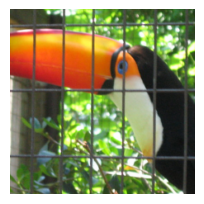

In [3]:
x, image_name = _load_image_tensor()
orig_np = _to_np(x[0])

print(f"Using device: {DEVICE}")
print(f"Model: {MODEL}")
print(f"Image: {image_name}")

plt.figure(figsize=(2.4, 2.4))
plt.imshow(orig_np)
plt.axis("off")
plt.show()


## 4. Attack: SARA

In this section, we evaluate the reconstruction performance of **SARA** under different token reduction strategies applied at the split layer. For each split point, we consider the following three scenarios:

* **Shuffling:** Tokens are randomly permuted before being transmitted to the cloud.
* **Dropping:** A random subset of tokens is discarded before transmission.
* **ToMe:** Tokens are merged using **Token Merging (ToMe)** [^tome].

SARA is evaluated for split points **2, 4, 6, 8, and 10**.

The figure below provides an overview of the **Spatially Aligned Reconstruction Attack (SARA)**. The attack consists of three stages:

1. **Token position prediction and spatial alignment**, where the original spatial arrangement of the transmitted tokens is estimated.
2. **Missing-token reconstruction** using a **Masked Autoencoder (MAE)** to recover tokens lost due to dropping or merging.
3. **Image reconstruction** with a convolutional decoder to generate the final reconstructed image.

<div align="center">
  <img src="images/attack.png" alt="Overview of the SARA pipeline" width="1000">
  <p>
    Overview of the <strong>Spatially Aligned Reconstruction Attack (SARA)</strong>. The pipeline consists of three stages: (1) token position prediction and spatial alignment, (2) missing-token reconstruction using a Masked Autoencoder (MAE), and (3) image reconstruction with a convolutional decoder.
  </p>
</div>

[^tome]: Daniel Bolya, Cheng-Yang Fu, Xiaoliang Dai, Peizhao Zhang, Christoph Feichtenhofer, and Judy Hoffman. *Token Merging: Your ViT But Faster*. arXiv:2210.09461, 2023. https://arxiv.org/abs/2210.09461


SARA split=2
SARA split=4
SARA split=6
SARA split=8
SARA split=10


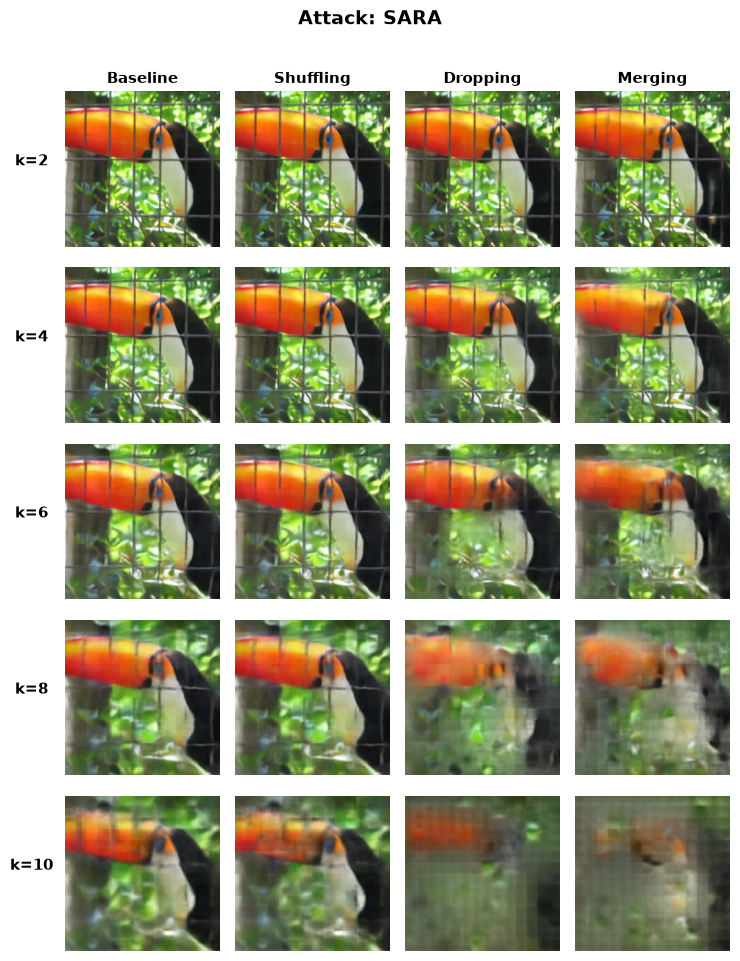

In [4]:
def run_sara_experiment(x: torch.Tensor, splits=SARA_SPLITS) -> list[dict]:
    sara_root = MODELS_ROOT / "sara"
    decoder_root = sara_root / "decoder"
    rows = []

    for k in splits:
        print(f"SARA split={k}")
        tag = f"s{k}"

        vit_b = _load_vit()
        client_b = ClientVit(vit_b, k).to(DEVICE).eval()
        dec = _load_attacker_decoder(decoder_root / f"{tag}.pth")
        with torch.no_grad():
            base_np = _to_np(dec(client_b(x))[0])
        del vit_b, client_b, dec
        if USE_CUDA:
            torch.cuda.empty_cache()

        sara = _load_sara(sara_root, tag)

        vit_sh = _load_vit()
        client_sh = ClientVit(vit_sh, k).to(DEVICE).eval()
        with torch.no_grad():
            shuf_np = _to_np(sara(_shuffle_tokens(client_sh(x)))[0])
        del vit_sh, client_sh
        if USE_CUDA:
            torch.cuda.empty_cache()

        vit_d = _load_vit()
        client_d = ClientVitRD(vit_d, k, enable_pos_embed=True).to(DEVICE).eval()
        with torch.no_grad():
            drop_np = _to_np(sara(client_d(x, R_VALUE))[0])
        del vit_d, client_d
        if USE_CUDA:
            torch.cuda.empty_cache()

        vit_m = _load_vit()
        client_m = ClientVitToMe(vit_m, k, enable_pos_embed=True).to(DEVICE).eval()
        with torch.no_grad():
            smashed, _, _ = client_m(x, R_VALUE)
            merge_np = _to_np(sara(smashed)[0])
        del vit_m, client_m, sara
        if USE_CUDA:
            torch.cuda.empty_cache()

        rows.append({
            "k": k,
            "orig": orig_np,
            "shuf": shuf_np,
            "drop": drop_np,
            "merge": merge_np,
            "base": base_np,
        })

    return rows

sara_rows = run_sara_experiment(x)
_plot_rows(sara_rows, "Attack: SARA")


## 5. Defense: Progressive Positional Embedding Removal

In this section, we evaluate our defense based on the **progressive, block-by-block removal of positional embeddings** from the Vision Transformer.

We analyze how this defense affects the images reconstructed by **SARA** under the following token manipulation strategies:

* **Shuffling:** The tokens are randomly permuted.
* **Dropping:** A random subset of tokens is removed.
* **Merging:** Tokens are combined using Token Merging (ToMe).

The defense is evaluated at split points **2, 4, 6, 8, and 10**. For each split point and token manipulation strategy, we compare the reconstructed images to assess how progressively removing positional information affects the effectiveness of the SARA attack.

PE-Removal Progressive split=2
PE-Removal Progressive split=4
PE-Removal Progressive split=6
PE-Removal Progressive split=8
PE-Removal Progressive split=10


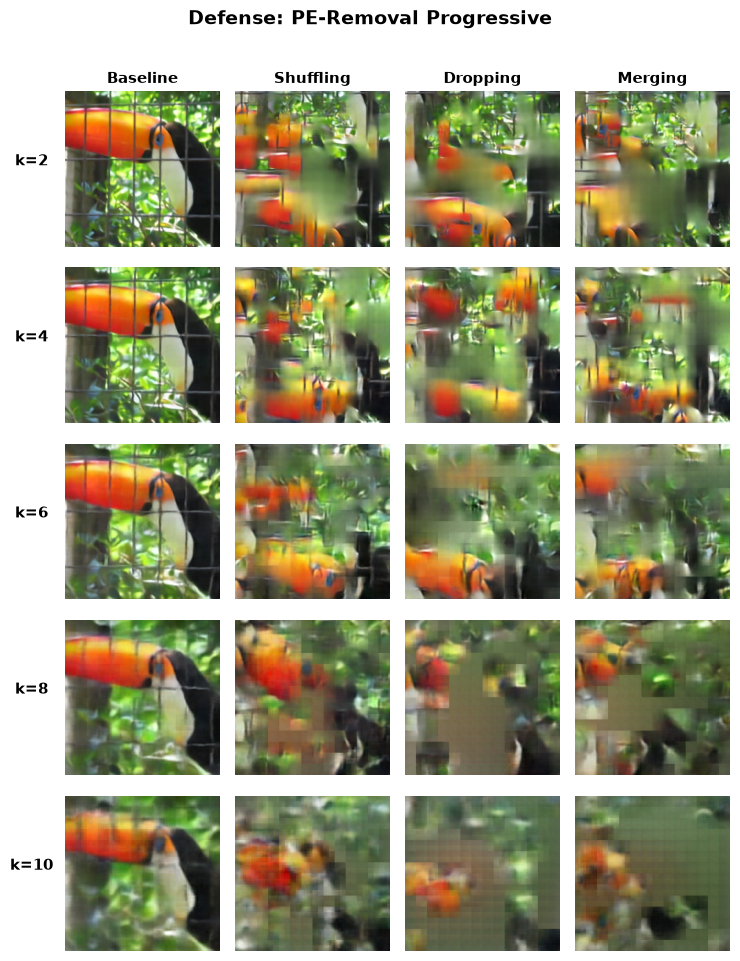

In [5]:
def run_pe_experiment(x: torch.Tensor, splits=PE_SPLITS, temperature: float = 4.0) -> list[dict]:
    pe_root = MODELS_ROOT / "pe_removal_progressive"
    client_root = pe_root / "client"
    sara_root = pe_root / "sara"
    base_dec_root = MODELS_ROOT / "sara" / "decoder"
    rows = []

    for k in splits:
        tag = f"s{k}_kl_T{temperature}"
        print(f"PE-Removal Progressive split={k}")

        vit_b = _load_vit()
        client_b = ClientVit(vit_b, k).to(DEVICE).eval()
        dec = _load_attacker_decoder(base_dec_root / f"s{k}.pth")
        with torch.no_grad():
            base_np = _to_np(dec(client_b(x))[0])
        del vit_b, client_b, dec
        if USE_CUDA:
            torch.cuda.empty_cache()

        client_ckpt = torch.load(client_root / f"{tag}.pth", map_location=DEVICE, weights_only=False)
        sara = _load_sara(sara_root, tag)

        vit_sh = _load_vit()
        client_sh = ClientVit(vit_sh, k, enable_pos_embed=False).to(DEVICE)
        client_sh.load_state_dict(client_ckpt["client_state_dict"])
        client_sh.eval()
        with torch.no_grad():
            shuf_np = _to_np(sara(_shuffle_tokens(client_sh(x)))[0])
        del vit_sh, client_sh
        if USE_CUDA:
            torch.cuda.empty_cache()

        vit_d = _load_vit()
        client_d = ClientVitRD(vit_d, k, enable_pos_embed=False).to(DEVICE)
        client_d.load_state_dict(client_ckpt["client_state_dict"])
        client_d.eval()
        with torch.no_grad():
            drop_np = _to_np(sara(client_d(x, R_VALUE))[0])
        del vit_d, client_d
        if USE_CUDA:
            torch.cuda.empty_cache()

        vit_m = _load_vit()
        client_m = ClientVitToMe(vit_m, k, enable_pos_embed=False).to(DEVICE)
        client_m.load_state_dict(client_ckpt["client_state_dict"], strict=False)
        client_m.eval()
        with torch.no_grad():
            smashed, _, _ = client_m(x, R_VALUE)
            merge_np = _to_np(sara(smashed)[0])
        del vit_m, client_m, sara
        if USE_CUDA:
            torch.cuda.empty_cache()

        rows.append({
            "k": k,
            "orig": orig_np,
            "shuf": shuf_np,
            "drop": drop_np,
            "merge": merge_np,
            "base": base_np,
        })

    return rows

pe_rows = run_pe_experiment(x)
_plot_rows(pe_rows, "Defense: PE-Removal Progressive")


## 6. Defense + Adversarial: Adversarial

We now show the resutls with the adversarial version of the defense.

Adversarial split=2
Adversarial split=4
Adversarial split=6
Adversarial split=8


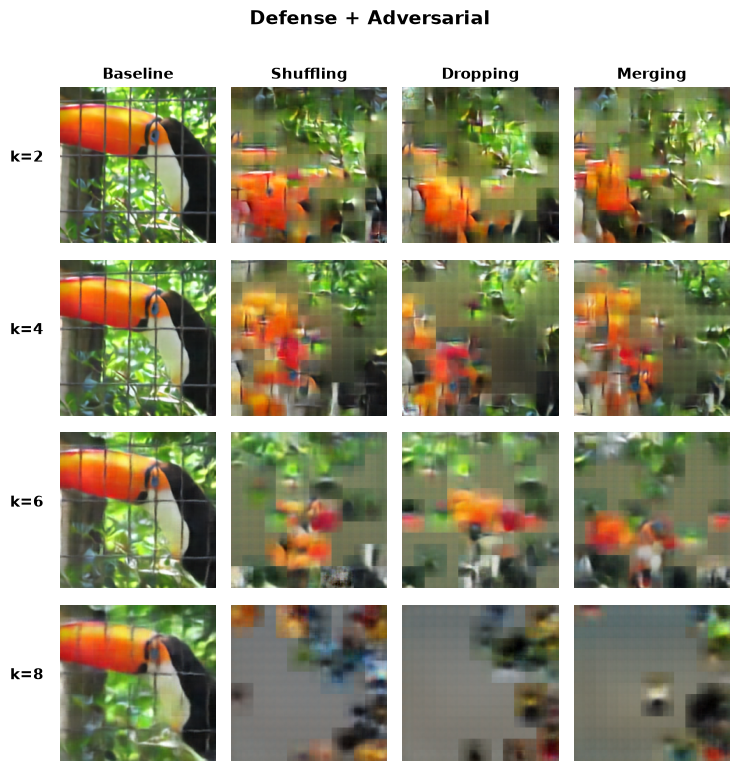

In [6]:
def run_adversarial_experiment(x: torch.Tensor, splits=ADVERSARIAL_SPLITS) -> list[dict]:
    adversarial_root = MODELS_ROOT / "adversarial"
    client_root = adversarial_root / "client"
    sara_root = adversarial_root / "sara"
    base_dec_root = MODELS_ROOT / "sara" / "decoder"
    rows = []

    for k in splits:
        tag = f"s{k}_full"
        print(f"Adversarial split={k}")

        vit_b = _load_vit()
        client_b = ClientVit(vit_b, k).to(DEVICE).eval()
        dec = _load_attacker_decoder(base_dec_root / f"s{k}.pth")
        with torch.no_grad():
            base_np = _to_np(dec(client_b(x))[0])
        del vit_b, client_b, dec
        if USE_CUDA:
            torch.cuda.empty_cache()

        client_ckpt = torch.load(client_root / f"{tag}.pth", map_location=DEVICE, weights_only=False)
        sara = _load_sara(sara_root, tag)

        vit_sh = _load_vit()
        client_sh = ClientVit(vit_sh, k, enable_pos_embed=False).to(DEVICE)
        client_sh.load_state_dict(client_ckpt["client_state_dict"])
        client_sh.eval()
        with torch.no_grad():
            shuf_np = _to_np(sara(_shuffle_tokens(client_sh(x)))[0])
        del vit_sh, client_sh
        if USE_CUDA:
            torch.cuda.empty_cache()

        vit_d = _load_vit()
        client_d = ClientVitRD(vit_d, k, enable_pos_embed=False).to(DEVICE)
        client_d.load_state_dict(client_ckpt["client_state_dict"])
        client_d.eval()
        with torch.no_grad():
            drop_np = _to_np(sara(client_d(x, R_VALUE))[0])
        del vit_d, client_d
        if USE_CUDA:
            torch.cuda.empty_cache()

        vit_m = _load_vit()
        client_m = ClientVitToMe(vit_m, k, enable_pos_embed=False).to(DEVICE)
        client_m.load_state_dict(client_ckpt["client_state_dict"], strict=False)
        client_m.eval()
        with torch.no_grad():
            smashed, _, _ = client_m(x, R_VALUE)
            merge_np = _to_np(sara(smashed)[0])
        del vit_m, client_m, sara
        if USE_CUDA:
            torch.cuda.empty_cache()

        rows.append({
            "k": k,
            "orig": orig_np,
            "shuf": shuf_np,
            "drop": drop_np,
            "merge": merge_np,
            "base": base_np,
        })

    return rows

adversarial_rows = run_adversarial_experiment(x)
_plot_rows(adversarial_rows, "Defense + Adversarial")


## 7. Comparison of the Reconstructions

This comparison uses only **split 4** and shows the four reconstruction settings in the same order for the three scenarios:

- No defense (`SARA`)
- Defense (`PE-Removal Progressive`)
- Defense + adversarial (`Adversarial`)


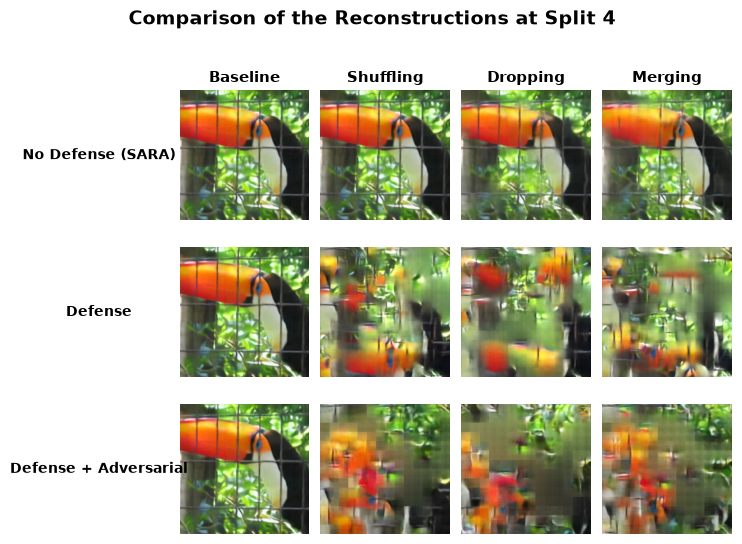

In [7]:
def _row_for_split(rows: list[dict], split: int) -> dict:
    for row in rows:
        if row["k"] == split:
            return row
    raise ValueError(f"Split {split} not found")

def _plot_split_comparison(split: int = 4) -> None:
    scenarios = [
        ("No Defense (SARA)", _row_for_split(sara_rows, split)),
        ("Defense", _row_for_split(pe_rows, split)),
        ("Defense + Adversarial", _row_for_split(adversarial_rows, split)),
    ]

    fig, axes = plt.subplots(len(scenarios), 4, figsize=(7.5, 5.4))
    if len(scenarios) == 1:
        axes = axes[np.newaxis, :]

    headers = ["Baseline", "Shuffling", "Dropping", "Merging"]
    for col, header in enumerate(headers):
        axes[0, col].set_title(header, fontsize=11, fontweight="bold")

    for row_idx, (label, row) in enumerate(scenarios):
        imgs = [row["base"], row["shuf"], row["drop"], row["merge"]]
        for col, img in enumerate(imgs):
            ax = axes[row_idx, col]
            ax.imshow(img)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
        axes[row_idx, 0].set_ylabel(label, rotation=0, labelpad=58, fontsize=10, fontweight="bold", va="center")

    fig.suptitle(f"Comparison of the Reconstructions at Split {split}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()

_plot_split_comparison(4)
